# The whole project in about 80 lines

**The story.** The memory is a list of N items. A question names an index *p* and asks for the
items at index p + 1 and p + 5 (wrapping round to the start, mod N). An attention head is a
helper that can fetch from one fixed distance, so this task needs exactly **2 helpers** (one per
distance). We start with **8**, and while training we keep asking of each helper: *if it went home,
could the others cover its job?* If yes, it fades out. The goal: end with exactly 2, without ever
breaking the model. (These are the starting sizes; section 1 shows how to change them.)

The code below is written to be read. It does the same thing as the project code in `src/hemo/`
(the last section lists the small differences).

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
torch.set_num_threads(4)

## 1. The sizes

Change **N**, **R** or **M**, then run the notebook from the top (Run All). The vector length D, the
distances and the number of starting heads are worked out from them. A smaller version that still
behaves like the real task: `N = 4, R = 2, M = 4`. Keep R at most N/2, so the distances differ.

**Keep M at 4 or more.** With tiny items (try `M = 1`), one head can cheat: it lets the item values
steer its own attention, so the attention weight itself carries information, and one head almost
solves a two-distance task. "One head, one equation" only holds when items are big enough that this
trick cannot carry them. The real experiments use M = 16.

In [2]:
# change these three ...
N = 8                # length of the memory list: positions with index 0 to 7
R = 2                # how many distances to look ahead; this is also how many heads the task needs
M = 4                # how many numbers make up each item in the list

# ... and everything below follows from them
NOISE = 4                                      # extra noise numbers in every vector (can be 0)
D = N + M + NOISE                              # length of every vector: label + item + noise
DK = 8                                         # size of each head: how many numbers each head works with
HEADS = 4 * R                                  # heads the model starts with: 4 times what it needs
DISTANCES = [1 + r * (N // R) for r in range(R)]   # R distances spread evenly round the list
print(f"memory of {N}, {R} distances {DISTANCES}, items of {M}, vectors of {D}, starting with {HEADS} heads")

memory of 8, 2 distances [1, 5], items of 4, vectors of 16, starting with 8 heads


## 2. The task

Each position in the memory is one vector: `[its index as a one-hot label | its item | a little noise]`.
Each question is `[the one-hot of p | noise]`. The answer is the items at index p + 1 and p + 5 (mod N).

In [3]:
def make_batch(B):
    labels = torch.eye(N).expand(B, N, N)                      # position j's label = one-hot of its index j
    items = torch.randn(B, N, M)                               # a random item at every position
    memory = torch.cat([labels, items, 0.1 * torch.randn(B, N, D - N - M)], -1)
    p = torch.randint(0, N, (B, N))                            # each question asks about an index p
    questions = torch.cat([F.one_hot(p, N).float(), 0.1 * torch.randn(B, N, D - N)], -1)
    rows = torch.arange(B)[:, None]
    answer = torch.cat([items[rows, (p + d) % N] for d in DISTANCES], -1)   # the items at index (p + d) mod N
    return questions, memory, answer

In [4]:
questions, memory, answer = make_batch(1)
print("memory", tuple(memory.shape), "questions", tuple(questions.shape), "answer", tuple(answer.shape))
p = int(questions[0, 0, :N].argmax())                          # the index question 0 asks about
needed = [(p + d) % N for d in DISTANCES]                     # the indices this question needs
print(f"question 0 asks about index {p}: needs the items at index {needed}")
print("its answer is exactly those items:",
      torch.equal(answer[0, 0], torch.cat([memory[0, j, N:N + M] for j in needed])))

memory (1, 8, 16) questions (1, 8, 16) answer (1, 8, 8)
question 0 asks about index 6: needs the items at index [7, 3]
its answer is exactly those items: True


## 3. Attention heads, each with a valve

Every head scores each position against the question, turns the scores into weights that add up to 1
(softmax), and returns the weighted average of the items. Each head's output is then multiplied by
its **valve** (1 = open, 0 = closed) before the output weights `W_o` combine the heads.

In [5]:
class Attention(nn.Module):
    def __init__(self, heads):
        super().__init__()
        self.H = heads
        self.W_q, self.W_k, self.W_v = (nn.Linear(D, heads * DK) for _ in range(3))
        self.W_o = nn.Linear(heads * DK, R * M)

    def head_outputs(self, questions, memory):                 # every head's weighted average
        split = lambda t: t.view(t.shape[0], N, self.H, DK).transpose(1, 2)      # cut into heads
        q, k, v = split(self.W_q(questions)), split(self.W_k(memory)), split(self.W_v(memory))
        weights = torch.softmax(q @ k.transpose(-2, -1) / DK ** 0.5, dim=-1)     # scores -> weights
        return weights @ v

    def forward(self, questions, memory, valves):
        out = self.head_outputs(questions, memory) * valves[None, :, None, None]  # THE VALVE
        return self.W_o(out.transpose(1, 2).reshape(len(questions), N, -1))

## 4. The collateral value of a head

Remove the head, let the remaining heads re-fit the output weights (least squares), and measure how
much the loss goes up. A head whose job another head can do is worth about 0, however busy it is.

In [6]:
@torch.no_grad()
def collateral_values(model, open_heads):
    questions, memory, answer = make_batch(256)                # a fresh batch to judge on
    outs = model.head_outputs(questions, memory).transpose(1, 2).reshape(-1, model.H, DK).double()
    target = answer.reshape(-1, R * M).double()

    def best_loss(heads):                                       # best read-out using only these heads
        Z = torch.cat([outs[:, h] for h in heads] + [torch.ones(len(target), 1, dtype=target.dtype)], 1)
        W = torch.linalg.lstsq(Z, target).solution
        return ((Z @ W - target) ** 2).mean().item()

    with_all = best_loss(open_heads)
    return {h: best_loss([o for o in open_heads if o != h]) - with_all for h in open_heads}

## 5. Training, with the collateral rule

An ordinary training loop. With `rule=True`, after a warm-up and then every 25 steps: value the open
heads, and close the cheapest one if it is worth less than the **price** (3% of the loss of a model
that knows nothing, which is about 1 here). A closed head's valve fades to 0 over 100 steps, so the
other heads can take over its job while it goes.

In [7]:
def train(heads, steps=2000, rule=False, price=0.03, warmup=400, every=25, fade=100, seed=0):
    torch.manual_seed(seed)
    model = Attention(heads)
    opt = torch.optim.AdamW(model.parameters(), lr=2e-3)
    valves, is_open = torch.ones(heads), torch.ones(heads)
    log = []
    for step in range(steps):
        questions, memory, answer = make_batch(128)
        loss = F.mse_loss(model(questions, memory, valves), answer)
        opt.zero_grad()
        loss.backward()
        opt.step()
        if rule:
            valves += (is_open - valves).clamp(-1 / fade, 1 / fade)            # fade toward open/closed
            if step >= warmup and step % every == 0:
                open_heads = [h for h in range(heads) if is_open[h] == 1]
                values = collateral_values(model, open_heads)
                cheapest = min(values, key=values.get)
                if values[cheapest] < price and len(open_heads) > 1:
                    is_open[cheapest] = 0                                      # close it
        log.append((loss.item(), int((valves > 0).sum())))
    return model, valves, log

## 6. Run it

First, how many heads does the task really need? Train with 1 head and with 2 (no rule).

In [8]:
for heads in range(1, R + 1):                                 # 1 head, 2 heads, ... up to R
    _, _, log = train(heads)
    print(f"{heads} head(s): final loss {sum(l for l, _ in log[-100:]) / 100:.4f}")

1 head(s): final loss 0.3798


2 head(s): final loss 0.0004


With fewer than R heads the loss stays high (a head fetches from one distance; the task has R).
With R heads it is solved. Now start with `HEADS` heads (4 times too many) and let the rule decide,
three times with different random starts:

In [9]:
logs = []
for seed in range(3):
    _, valves, log = train(HEADS, rule=True, seed=seed)
    logs.append(log)
    print(f"seed {seed}: heads left {int((valves > 0).sum())} of {HEADS} (task needs {R}),  final loss "
          f"{sum(l for l, _ in log[-100:]) / 100:.4f},  worst loss after step 1000 {max(l for l, _ in log[1000:]):.4f}")

seed 0: heads left 2 of 8 (task needs 2),  final loss 0.0003,  worst loss after step 1000 0.0011


seed 1: heads left 2 of 8 (task needs 2),  final loss 0.0002,  worst loss after step 1000 0.0009


seed 2: heads left 2 of 8 (task needs 2),  final loss 0.0002,  worst loss after step 1000 0.0027


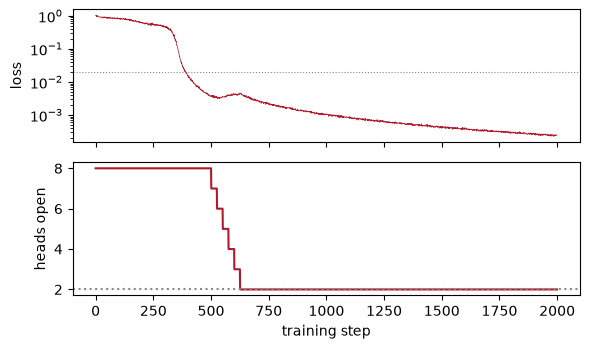

In [10]:
loss, heads = zip(*logs[0])
fig, ax = plt.subplots(2, 1, figsize=(6, 3.6), sharex=True)
ax[0].semilogy(loss, color="#b2182b", lw=0.5); ax[0].set_ylabel("loss")
ax[0].axhline(0.02, color="#888", ls=":", lw=0.8)              # the 'solved' bar
ax[1].plot(heads, color="#b2182b"); ax[1].axhline(R, color="#888", ls=":")
ax[1].set_ylabel("heads open"); ax[1].set_xlabel("training step")
plt.tight_layout(); plt.show()

With the starting sizes, every run ends with exactly the R = 2 heads the task needs, and the loss
stays far below the solved bar (dotted) the whole way down. Try other sizes in section 1.

## 7. How this compares with the project code

| here | in `src/hemo/` | difference |
|---|---|---|
| `make_batch` | `tasks.make_batch` | the project also adds noise to the labels |
| `Attention` | `model.CrossAttn` / `HemoAttn` | same; the project stores more for the analyses |
| `collateral_values` | `HemoAttn.probe_ischemia` | the project gets the same numbers with one matrix inverse instead of one re-fit per head (faster) |
| the `if rule:` block | `HemoAttn.local_step`, `relax_tone` | the project also **reopens** a closed head worth more than twice the price |
| `train` | `train.train` | the project adds a learning-rate schedule and gradient clipping |
| sizes 8 / 2 / 8 heads | `Cfg` | the experiments use a memory of 16, 4 distances, 32 heads, 4000 steps |

The full experiments (hundreds of runs, see `walkthrough_by_hand.ipynb` section 8 and the paper)
found the same as here, at full size: the rule kept exactly the needed number of heads in 47 of 50
runs and never broke the model in 50 of 50, which no other rule tested managed.